# 10.3 — Cópulas y correlación de default

Cierra M10. Las curvas de hazard marginales (10.2) no determinan por sí solas la
distribución CONJUNTA de defaults de varios nombres — se necesita una **cópula** para
acoplarlos. La **cópula gaussiana** (Li, 2000) es el estándar de facto (pre y post-2008):
transforma cada tiempo de default marginal a una uniforme vía su propia supervivencia, y
acopla esas uniformes con un vector gaussiano correlacionado.

## 0. Configuración

5 nombres de crédito con curvas de hazard marginales distintas (intensidad constante por
nombre — simplificación pedagógica; en producción cada nombre tendría su propio bootstrap
de 10.2).

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

n_names = 5
lambdas = np.array([0.010, 0.015, 0.020, 0.030, 0.050])  # hazard constante por nombre


def survival_i(t, i):
    return np.exp(-lambdas[i] * t)

## 1. Simulación de la cópula gaussiana

$Z\sim N(0,\Sigma)$ (correlación $\rho$ constante entre pares), $U_i=\Phi(Z_i)$,
$\tau_i=-\ln(U_i)/\lambda_i$ (inversión de la supervivencia exponencial marginal, dado
$U_i$). Esto acopla los $\tau_i$ vía $\rho$ sin distorsionar sus distribuciones
marginales — cada $\tau_i$, mirado por separado, sigue siendo exactamente
$\text{Exp}(\lambda_i)$.

**Aclaración de nomenclatura, importante y fuente frecuente de errores en la práctica**:
este $\rho$ es el **parámetro de correlación de la cópula** — la correlación del vector
gaussiano LATENTE $Z$ que acopla los tiempos de default. NO es la **correlación de
default**, que es la correlación de Pearson de los indicadores binarios
$\mathbb{1}\{\tau_i\le T\}$ a un horizonte $T$ dado (la cantidad de Li, 2000, que
realmente importa para tranches de una cesta). Confundir ambas es el error clásico del
área: como el mapeo $U_i=\Phi(Z_i)$ es no lineal y además cada indicador binario tiene su
propia varianza (que depende de la probabilidad marginal de default $p_i(T)$), la
correlación de default resultante es **siempre menor** que $\rho$ de la cópula, y la
brecha entre ambas se cuantifica en la Sección 2.

In [2]:
def simulate_default_times(rho, n_paths, rng):
    Sigma = np.full((n_names, n_names), rho)
    np.fill_diagonal(Sigma, 1.0)
    chol = np.linalg.cholesky(Sigma)
    Z = rng.standard_normal((n_paths, n_names)) @ chol.T
    U = norm.cdf(Z)
    return -np.log(U) / lambdas[None, :]


n_paths = 200_000
tau = simulate_default_times(0.3, n_paths, rng)

### Demo 1 — las marginales no se distorsionan por la cópula

Acoplar los tiempos de default con una correlación $\rho$ NO debería cambiar la probabilidad de supervivencia de cada nombre por separado — la cópula solo controla cómo se mueven JUNTOS, no sus distribuciones individuales. Verificamos, para cada uno de los 5 nombres, que la fracción simulada de trayectorias con $\tau_i>t$ sigue coincidiendo con la exponencial exacta de ese nombre.

In [3]:
t_check = 5.0
marginal_checks = []
for i in range(n_names):
    surv_sim = np.mean(tau[:, i] > t_check)
    surv_exact = survival_i(t_check, i)
    se = np.sqrt(surv_exact * (1 - surv_exact) / n_paths)
    z = (surv_sim - surv_exact) / se
    marginal_checks.append(z)
    print(f"nombre {i} (lambda={lambdas[i]}): P(tau>{t_check}) sim={surv_sim:.4f} "
          f"exacta={surv_exact:.4f} z={z:.2f}")

nombre 0 (lambda=0.01): P(tau>5.0) sim=0.9516 exacta=0.9512 z=0.79
nombre 1 (lambda=0.015): P(tau>5.0) sim=0.9274 exacta=0.9277 z=-0.62
nombre 2 (lambda=0.02): P(tau>5.0) sim=0.9045 exacta=0.9048 z=-0.51
nombre 3 (lambda=0.03): P(tau>5.0) sim=0.8603 exacta=0.8607 z=-0.55
nombre 4 (lambda=0.05): P(tau>5.0) sim=0.7792 exacta=0.7788 z=0.40


### Demo 2 — distribución del número de defaults en la cesta

Contamos, en cada trayectoria simulada, cuántos de los 5 nombres defaultearon antes de un horizonte fijo, y repetimos para tres valores de $\rho$. Con $\rho=0$ los defaults son independientes (la distribución del conteo se parece a una binomial, concentrada en el centro); con $\rho$ alto, los nombres tienden a defaultear todos juntos o ninguno — la masa se desplaza hacia los extremos (0 defaults o los 5) y se vacía el centro. Este es exactamente el mecanismo que hace la correlación de default relevante para instrumentos de tramos (tranches) de una cesta.

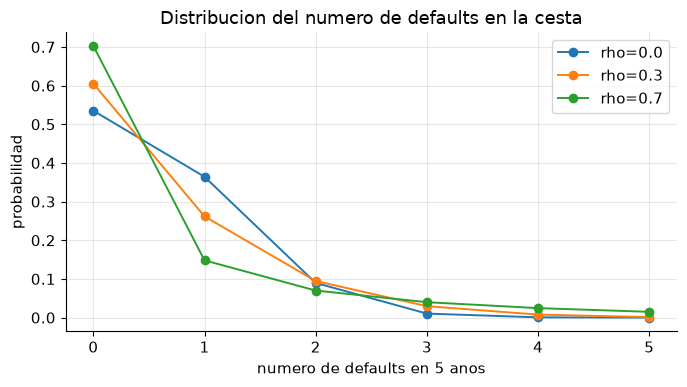

a mayor parametro de correlacion de la copula (rho), mas masa en los extremos
(0 defaults o todos default) -- la copula vuelve la distribucion conjunta mas bimodal.


In [4]:
horizon = 5.0
fig, ax = plt.subplots(figsize=(7, 4))
for rho in [0.0, 0.3, 0.7]:
    tau_rho = simulate_default_times(rho if rho > 0 else 1e-6, n_paths, rng)
    n_defaults = np.sum(tau_rho <= horizon, axis=1)
    counts = np.bincount(n_defaults, minlength=n_names + 1) / n_paths
    ax.plot(range(n_names + 1), counts, "o-", label=f"rho={rho}")
ax.set_xlabel("numero de defaults en 5 anos"); ax.set_ylabel("probabilidad")
ax.set_title("Distribucion del numero de defaults en la cesta")
ax.legend(); fig.tight_layout(); plt.show()

print("a mayor parametro de correlacion de la copula (rho), mas masa en los extremos")
print("(0 defaults o todos default) -- la copula vuelve la distribucion conjunta mas bimodal.")

### Demo 3 — first-to-default: límites $\rho\to0$ y $\rho\to1$

Dos casos límite con respuesta conocida de antemano, útiles para verificar que la cópula está bien implementada. Con $\rho\to0$ (independencia), la probabilidad de que NINGÚN nombre haya defaultado antes de $t$ es simplemente el producto de las supervivencias individuales — no se necesita la cópula para calcularlo, así que sirve de control. Con $\rho\to1$ (comonotonía perfecta), todos los tiempos de default quedan perfectamente ordenados por su hazard: el nombre con mayor $\lambda$ (el más riesgoso) debería ser casi siempre el primero en defaultear.

In [5]:
t_check2 = 3.0

tau_rho0 = simulate_default_times(1e-6, n_paths, rng)
surv_min_sim = np.mean(tau_rho0.min(axis=1) > t_check2)
surv_min_exact = np.prod([survival_i(t_check2, i) for i in range(n_names)])
se_min = np.sqrt(surv_min_exact * (1 - surv_min_exact) / n_paths)
z_rho0 = (surv_min_sim - surv_min_exact) / se_min
print(f"rho~0: P(first-to-default > {t_check2}) sim={surv_min_sim:.4f} "
      f"exacta (prod. de marginales)={surv_min_exact:.4f} z={z_rho0:.2f}")

tau_rho1 = simulate_default_times(0.999999, n_paths, rng)
first_defaulter = np.argmin(tau_rho1, axis=1)
frac_highest_first = np.mean(first_defaulter == np.argmax(lambdas))
print(f"\nrho~1: fraccion de trayectorias donde el nombre de mayor hazard defaultea primero: "
      f"{frac_highest_first:.4f} (comonotonia perfecta esperada, >95%)")

rho~0: P(first-to-default > 3.0) sim=0.6877 exacta (prod. de marginales)=0.6873 z=0.36

rho~1: fraccion de trayectorias donde el nombre de mayor hazard defaultea primero: 1.0000 (comonotonia perfecta esperada, >95%)


## 2. La brecha entre $\rho$ de la cópula y la correlación de default

Cerramos la aclaración de nomenclatura de la Sección 1 con números. La correlación de
default real a un horizonte $T$ es la correlación de Pearson de los indicadores
$\mathbb{1}\{\tau_i\le T\}$ — dos variables Bernoulli con probabilidad marginal
$p_i(T)=1-e^{-\lambda_i T}$. Como $\mathbb{1}\{\tau_i\le T\}=\mathbb{1}\{U_i\le
p_i(T)\}=\mathbb{1}\{Z_i\le x_i\}$ con $x_i=\Phi^{-1}(p_i(T))$, y $(Z_i,Z_j)$ es
gaussiano bivariado con correlación $\rho$, la probabilidad conjunta de default es
$\Phi_2(x_i,x_j;\rho)$ (la CDF normal bivariada, `scipy.stats.multivariate_normal`), y de
ahí la fórmula **semianalítica** para la correlación de default de un par:

$$\rho_{\text{default}}(i,j)=\frac{\Phi_2(x_i,x_j;\rho)-p_i(T)\,p_j(T)}
{\sqrt{p_i(T)(1-p_i(T))\,p_j(T)(1-p_j(T))}}.$$

Esto nos da una validación real, no solo ilustrativa: comparamos esta fórmula cerrada
contra la correlación de default estimada por Monte Carlo directamente de `tau` (la
simulación con $\rho=0.3$ y `horizon=5.0` ya hechas en las Demos 2 y 3), para los
$\binom{5}{2}=10$ pares de nombres. El error estándar de cada estimado MC se obtiene
partiendo las 200,000 trayectorias en 20 bloques y usando la dispersión entre bloques —
así no dependemos de ninguna fórmula de SE para correlación de Bernoulli, que es
delicada.

In [6]:
from itertools import combinations
from scipy.stats import multivariate_normal

p_marginal = 1 - np.exp(-lambdas * horizon)  # PD marginal de cada nombre a horizon=5.0
D_indicator = (tau <= horizon).astype(float)  # tau y horizon vienen de las Demos 2/3 (rho=0.3)

n_blocks = 20
block_size = n_paths // n_blocks

pairs = list(combinations(range(n_names), 2))
rho_default_empirical, rho_default_analytic, z_scores = [], [], []
for (i, j) in pairs:
    emp_full = np.corrcoef(D_indicator[:, i], D_indicator[:, j])[0, 1]

    block_corrs = [
        np.corrcoef(D_indicator[k * block_size:(k + 1) * block_size, i],
                     D_indicator[k * block_size:(k + 1) * block_size, j])[0, 1]
        for k in range(n_blocks)
    ]
    se = np.std(block_corrs, ddof=1) / np.sqrt(n_blocks)

    xi, xj = norm.ppf(p_marginal[i]), norm.ppf(p_marginal[j])
    joint = multivariate_normal.cdf([xi, xj], mean=[0, 0], cov=[[1, 0.3], [0.3, 1]])
    ana = (joint - p_marginal[i] * p_marginal[j]) / np.sqrt(
        p_marginal[i] * (1 - p_marginal[i]) * p_marginal[j] * (1 - p_marginal[j]))

    z = (emp_full - ana) / se
    rho_default_empirical.append(emp_full)
    rho_default_analytic.append(ana)
    z_scores.append(z)

    print(f"pares ({i},{j}): rho_default MC={emp_full:.4f}  formula={ana:.4f}  SE={se:.4f}  z={z:.2f}")

max_abs_z_gap = np.max(np.abs(z_scores))
print(f"\nrho_copula=0.30, horizon={horizon}: rho_default MC en rango "
      f"[{min(rho_default_empirical):.4f}, {max(rho_default_empirical):.4f}] "
      f"-- muy por debajo de rho_copula=0.30 (max|z| MC vs formula = {max_abs_z_gap:.2f})")

pares (0,1): rho_default MC=0.1027  formula=0.1044  SE=0.0028  z=-0.60
pares (0,2): rho_default MC=0.1149  formula=0.1094  SE=0.0041  z=1.37
pares (0,3): rho_default MC=0.1097  formula=0.1151  SE=0.0032  z=-1.68
pares (0,4): rho_default MC=0.1190  formula=0.1190  SE=0.0028  z=0.00
pares (1,2): rho_default MC=0.1217  formula=0.1198  SE=0.0028  z=0.70
pares (1,3): rho_default MC=0.1313  formula=0.1270  SE=0.0036  z=1.18
pares (1,4): rho_default MC=0.1290  formula=0.1328  SE=0.0027  z=-1.41
pares (2,3): rho_default MC=0.1322  formula=0.1351  SE=0.0033  z=-0.90
pares (2,4): rho_default MC=0.1469  formula=0.1424  SE=0.0025  z=1.84
pares (3,4): rho_default MC=0.1543  formula=0.1551  SE=0.0027  z=-0.32

rho_copula=0.30, horizon=5.0: rho_default MC en rango [0.1027, 0.1543] -- muy por debajo de rho_copula=0.30 (max|z| MC vs formula = 1.84)


### Demo 5 — barrido $\rho_{\text{default}}(\rho_{\text{copula}})$: la brecha en función del nivel

Con la fórmula semianalítica ya validada contra Monte Carlo, la usamos (es mucho más
rápida que resimular para cada punto) para barrer $\rho_{\text{copula}}$ de 0 a 0.9 y
graficar el promedio de $\rho_{\text{default}}$ sobre los 10 pares, junto a la diagonal
$\rho_{\text{default}}=\rho_{\text{copula}}$. La curva debe quedar estrictamente por
debajo de la diagonal en todo el rango — la cópula gaussiana atenúa la correlación al
pasar de las variables latentes continuas a los indicadores binarios de default.

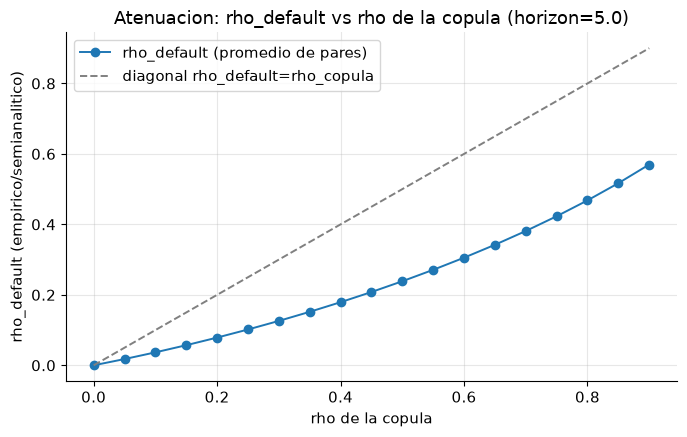

  rho_copula   rho_default
        0.00        0.0000
        0.05        0.0178
        0.10        0.0368
        0.15        0.0571
        0.20        0.0787
        0.25        0.1017
        0.30        0.1260
        0.35        0.1518
        0.40        0.1791
        0.45        0.2080
        0.50        0.2386
        0.55        0.2710
        0.60        0.3054
        0.65        0.3420
        0.70        0.3811
        0.75        0.4230
        0.80        0.4681
        0.85        0.5169
        0.90        0.5699

rho_default < rho_copula en todo el interior de la malla: True
rho_default monotona creciente en rho_copula: True


In [7]:
def rho_default_mean(rho_copula, horizon_):
    p_h = 1 - np.exp(-lambdas * horizon_)
    vals = []
    for (i, j) in pairs:
        xi, xj = norm.ppf(p_h[i]), norm.ppf(p_h[j])
        cov = [[1, rho_copula], [rho_copula, 1]]
        joint = multivariate_normal.cdf([xi, xj], mean=[0, 0], cov=cov)
        vals.append((joint - p_h[i] * p_h[j]) / np.sqrt(p_h[i] * (1 - p_h[i]) * p_h[j] * (1 - p_h[j])))
    return np.mean(vals)


rho_copula_grid = np.linspace(0.0, 0.9, 19)
rho_default_grid = np.array([rho_default_mean(r, horizon) for r in rho_copula_grid])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rho_copula_grid, rho_default_grid, "o-", label="rho_default (promedio de pares)")
ax.plot(rho_copula_grid, rho_copula_grid, "--", color="gray", label="diagonal rho_default=rho_copula")
ax.set_xlabel("rho de la copula"); ax.set_ylabel("rho_default (empirico/semianalitico)")
ax.set_title(f"Atenuacion: rho_default vs rho de la copula (horizon={horizon})")
ax.legend(); fig.tight_layout(); plt.show()

print(f"{'rho_copula':>12}  {'rho_default':>12}")
for r, rd in zip(rho_copula_grid, rho_default_grid):
    print(f"{r:12.2f}  {rd:12.4f}")

is_below_diagonal = np.all(rho_default_grid[1:-1] < rho_copula_grid[1:-1])
is_monotone = np.all(np.diff(rho_default_grid) > 0)
print(f"\nrho_default < rho_copula en todo el interior de la malla: {is_below_diagonal}")
print(f"rho_default monotona creciente en rho_copula: {is_monotone}")

### Demo 6 — la brecha depende del horizonte y de la rareza del default

El barrido anterior fija `horizon=5.0`. Repetimos para varios horizontes: la brecha entre
$\rho_{\text{copula}}$ y $\rho_{\text{default}}$ NO es una constante del modelo — depende
de qué tan raro es el default marginal a ese horizonte. Con horizontes cortos (PD marginal
baja, defaults raros) las dos colas de la normal bivariada que hay que integrar están muy
lejos del centro, y la correlación de los indicadores binarios queda mucho más atenuada
que con horizontes largos (PD marginal alta). Esto es precisamente lo que hace peligrosa
la confusión entre ambas correlaciones para tranches: si un modelo de cesta calibra "la"
correlación con datos de un horizonte y la aplica a tranches con exposición a otro
horizonte (o a nombres con hazards muy distintos), la brecha real puede ser varias veces
mayor o menor que la asumida.

rho_copula=0.3  horizon=  0.5  PD_marginal_promedio=0.0124  rho_default=0.0474
rho_copula=0.3  horizon=  1.0  PD_marginal_promedio=0.0246  rho_default=0.0657
rho_copula=0.3  horizon=  3.0  PD_marginal_promedio=0.0714  rho_default=0.1047
rho_copula=0.3  horizon=  5.0  PD_marginal_promedio=0.1153  rho_default=0.1260
rho_copula=0.3  horizon= 10.0  PD_marginal_promedio=0.2137  rho_default=0.1542
rho_copula=0.3  horizon= 20.0  PD_marginal_promedio=0.3707  rho_default=0.1736

rho_copula=0.7  horizon=  0.5  PD_marginal_promedio=0.0124  rho_default=0.2527
rho_copula=0.7  horizon=  1.0  PD_marginal_promedio=0.0246  rho_default=0.2897
rho_copula=0.7  horizon=  3.0  PD_marginal_promedio=0.0714  rho_default=0.3528
rho_copula=0.7  horizon=  5.0  PD_marginal_promedio=0.1153  rho_default=0.3811
rho_copula=0.7  horizon= 10.0  PD_marginal_promedio=0.2137  rho_default=0.4128
rho_copula=0.7  horizon= 20.0  PD_marginal_promedio=0.3707  rho_default=0.4266



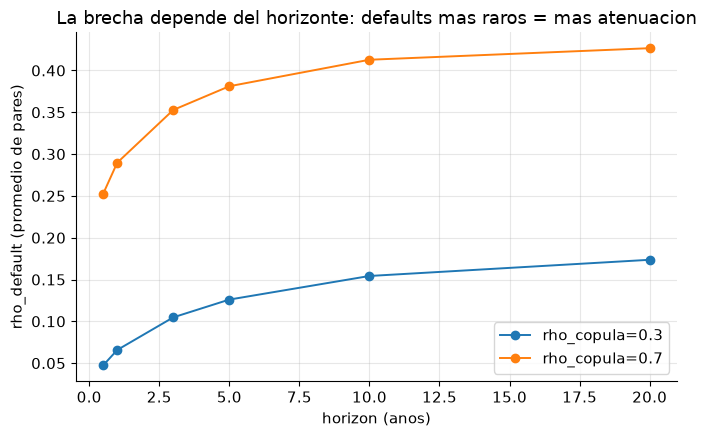

atenuacion con rho_copula=0.3: horizon=0.5 -> 84.2% de atenuacion vs horizon=20.0 -> 42.1%


In [8]:
horizons_grid = [0.5, 1.0, 3.0, 5.0, 10.0, 20.0]
rho_fixed_list = [0.3, 0.7]

fig, ax = plt.subplots(figsize=(7, 4.5))
for rho_fixed in rho_fixed_list:
    rd_by_horizon = [rho_default_mean(rho_fixed, h) for h in horizons_grid]
    ax.plot(horizons_grid, rd_by_horizon, "o-", label=f"rho_copula={rho_fixed}")
    avg_pd_by_horizon = [np.mean(1 - np.exp(-lambdas * h)) for h in horizons_grid]
    for h, rd, pdavg in zip(horizons_grid, rd_by_horizon, avg_pd_by_horizon):
        print(f"rho_copula={rho_fixed}  horizon={h:5.1f}  PD_marginal_promedio={pdavg:.4f}  "
              f"rho_default={rd:.4f}")
    print()

ax.set_xlabel("horizon (anos)"); ax.set_ylabel("rho_default (promedio de pares)")
ax.set_title("La brecha depende del horizonte: defaults mas raros = mas atenuacion")
ax.legend(); fig.tight_layout(); plt.show()

rd_short = rho_default_mean(0.3, horizons_grid[0])
rd_long = rho_default_mean(0.3, horizons_grid[-1])
attenuation_short = 1 - rd_short / 0.3
attenuation_long = 1 - rd_long / 0.3
print(f"atenuacion con rho_copula=0.3: horizon={horizons_grid[0]} -> "
      f"{attenuation_short:.1%} de atenuacion vs horizon={horizons_grid[-1]} -> {attenuation_long:.1%}")

## 3. Validación

Siete chequeos: los tres originales -- (1) las marginales de la Demo 1 no se distorsionan
por la cópula, dentro de 3 SE en cada uno de los 5 nombres; (2) el límite $\rho\to0$
recupera el producto de supervivencias marginales; (3) el límite $\rho\to1$ da
comonotonía casi perfecta -- más cuatro nuevos, sobre la brecha
$\rho_{\text{copula}}$ vs $\rho_{\text{default}}$ de la Sección 2: (4) la fórmula
semianalítica coincide con Monte Carlo dentro de pocos SE (bloque-bootstrap, Demo 4);
(5) $\rho_{\text{copula}}=0\Rightarrow\rho_{\text{default}}\approx0$; (6)
$\rho_{\text{default}}$ es estrictamente menor que $\rho_{\text{copula}}$ en el interior
de la malla y monótona creciente en $\rho_{\text{copula}}$ (Demo 5).

In [9]:
check1 = np.all(np.abs(marginal_checks) <= 3.0)
print(f"1. marginales no distorsionadas por la copula: max|z|={np.max(np.abs(marginal_checks)):.2f} (<=3? {check1})")

check2 = abs(z_rho0) <= 3.0
print(f"2. limite rho->0 (first-to-default) recupera prod. de supervivencias marginales: "
      f"z={z_rho0:.2f} (<=3? {check2})")

check3 = frac_highest_first > 0.95
print(f"3. limite rho->1 (comonotonia): fraccion={frac_highest_first:.4f} (>0.95? {check3})")

check4 = max_abs_z_gap <= 3.0
print(f"4. formula semianalitica de rho_default vs Monte Carlo: max|z|={max_abs_z_gap:.2f} (<=3? {check4})")

rho_default_at_zero = rho_default_mean(0.0, horizon)
check5 = abs(rho_default_at_zero) < 0.01
print(f"5. rho_copula=0 => rho_default~0: rho_default={rho_default_at_zero:.5f} (<0.01? {check5})")

check6 = is_below_diagonal
print(f"6. rho_default < rho_copula estrictamente en el interior de la malla (0,0.9): {check6}")

check7 = is_monotone
print(f"7. rho_default monotona creciente en rho_copula: {check7}")

assert check1
assert check2
assert check3
assert check4
assert check5
assert check6
assert check7
print("\nValidacion completa: 7/7 dentro de tolerancia.")

1. marginales no distorsionadas por la copula: max|z|=0.79 (<=3? True)
2. limite rho->0 (first-to-default) recupera prod. de supervivencias marginales: z=0.36 (<=3? True)
3. limite rho->1 (comonotonia): fraccion=1.0000 (>0.95? True)
4. formula semianalitica de rho_default vs Monte Carlo: max|z|=1.84 (<=3? True)
5. rho_copula=0 => rho_default~0: rho_default=0.00000 (<0.01? True)
6. rho_default < rho_copula estrictamente en el interior de la malla (0,0.9): True
7. rho_default monotona creciente en rho_copula: True

Validacion completa: 7/7 dentro de tolerancia.


## Referencias

- Li, D. (2000). *On Default Correlation: A Copula Function Approach*. Journal of Fixed
  Income, 9(4), 43-54. -- introduce la correlación de default como propiedad de los
  indicadores $\mathbb{1}\{\tau_i\le T\}$, y la cópula gaussiana como mecanismo para
  generarla; la confusión práctica entre $\rho$ de la cópula y esta cantidad (Sección 2)
  es uno de los errores de modelado de crédito más citados tras 2008.
- Schönbucher, P., Schubert, D. (2001). *Copula-dependent default risk in intensity
  models*.